In [18]:
import numpy as np
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from tqdm.notebook import tqdm

# from modulars.plot_rr import plot_a_few_trajectories_1d, plot_mean_band_rrs_1d
from modulars import run_restart_multid_fullrank, gaussian_multid
from modulars.distributions import gaussian_multid_posterior, ensure_arr
from modulars.utils import check_all_int_or_float_or_1darrays, check_all_covar_shaped_arrays
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoDiagonalNormal
from numpyro.optim import Adam
import numpyro.distributions as dist

In [19]:
# this is 40 dimensions
mu_prior = np.zeros(40)
sigma_prior = np.ones(40) * 10 # diag std of prior
mu_like = 2.0
sigma_like = 1.0 # std of likelihood
max_iters = 200_000
n_obs = 3
dim = 40
np.random.seed(42)

DIAG = True

# Generate observations for each dimension
observed_data = gaussian_multid(
    seed=42, n_samples=n_obs, mu_like=mu_like,
    scale_like=sigma_like, dim=dim)
# compute known posterior,this is the posterior 
# diagonal standard deviation vector as true_sigma_post
true_mu_post, true_sigma_post = gaussian_multid_posterior(
    observed_data, n_samples=n_obs,
    mu_prior=mu_prior, scale_prior=sigma_prior,
    scale_like=1.0, std_devs=True,
    diag=DIAG, dim=40)

In [20]:
if DIAG:
    print("Running diagonal covariance case")
    # this runs the easiest case where all dimensions are i.i.d.
    # note that this assumes the input parameters are standard deviations
    # only run this cell if diag is True and all of the parameters are floats or 1d arrays
    assert DIAG, "this code only works for diagonal covariance matrices"
    assert check_all_int_or_float_or_1darrays(mu_prior, sigma_prior, mu_like, sigma_like), "all parameters must be floats or 1d arrays"

    def model(y=None):
        mu = numpyro.sample('mu',
            dist.MultivariateNormal(
                loc = ensure_arr(mu_prior, dim),
                covariance_matrix=jnp.diag(ensure_arr(sigma_prior**2, dim)))
        )
        numpyro.sample('z',
            dist.MultivariateNormal(
                loc = mu,
                covariance_matrix = jnp.diag(ensure_arr(sigma_like**2, dim))),
            obs=y
        )

Running diagonal covariance case


In [21]:
if not DIAG:
    print ("Running non-diagonal covariance case")
    # this is if we have non-diagonal covariance matrices,
    # which means that we need the full covariance matrices
    # inputs should be 2d arrays of shape (dim, dim)
    assert check_all_covar_shaped_arrays(dim, sigma_prior, sigma_like), "must input correctly shaped ({dim}, {dim})covariance matrices"
    def model(y=None):
        mu = numpyro.sample('mu',
            dist.MultivariateNormal(
                loc = ensure_arr(mu_prior, dim), covariance_matrix=sigma_prior)
        )
        numpyro.sample('z',
            dist.MultivariateNormal(
                loc = mu, covariance_matrix = sigma_like),
            obs=y
        )

In [22]:
results = []
for seed in tqdm(range(10)):
    result = run_restart_multid_fullrank(
        seed, model, observed_data, 'mu', 30_000,
        dim=40
        )
    results.append(result)


  0%|          | 0/10 [00:00<?, ?it/s]

In [23]:
from modulars.utils import apply_traj_transform_multid
single_means, single_stds, multi_means, multi_stds = \
    apply_traj_transform_multid(results)


  0%|          | 0/10 [00:00<?, ?it/s]

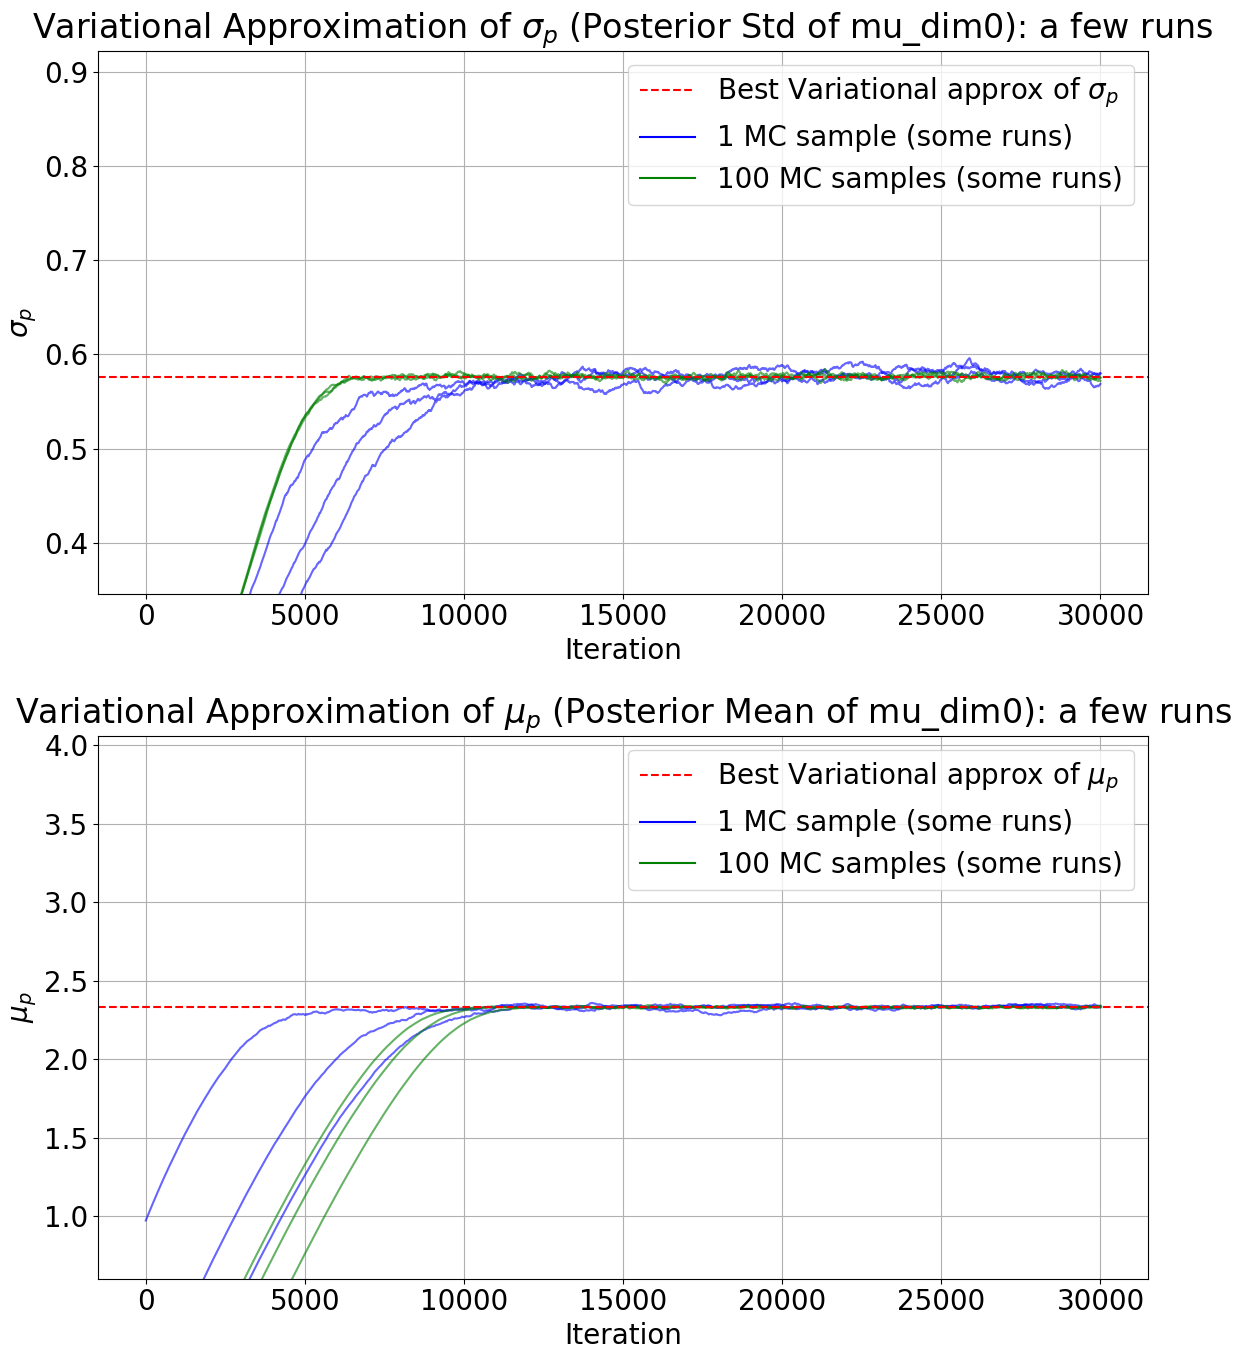

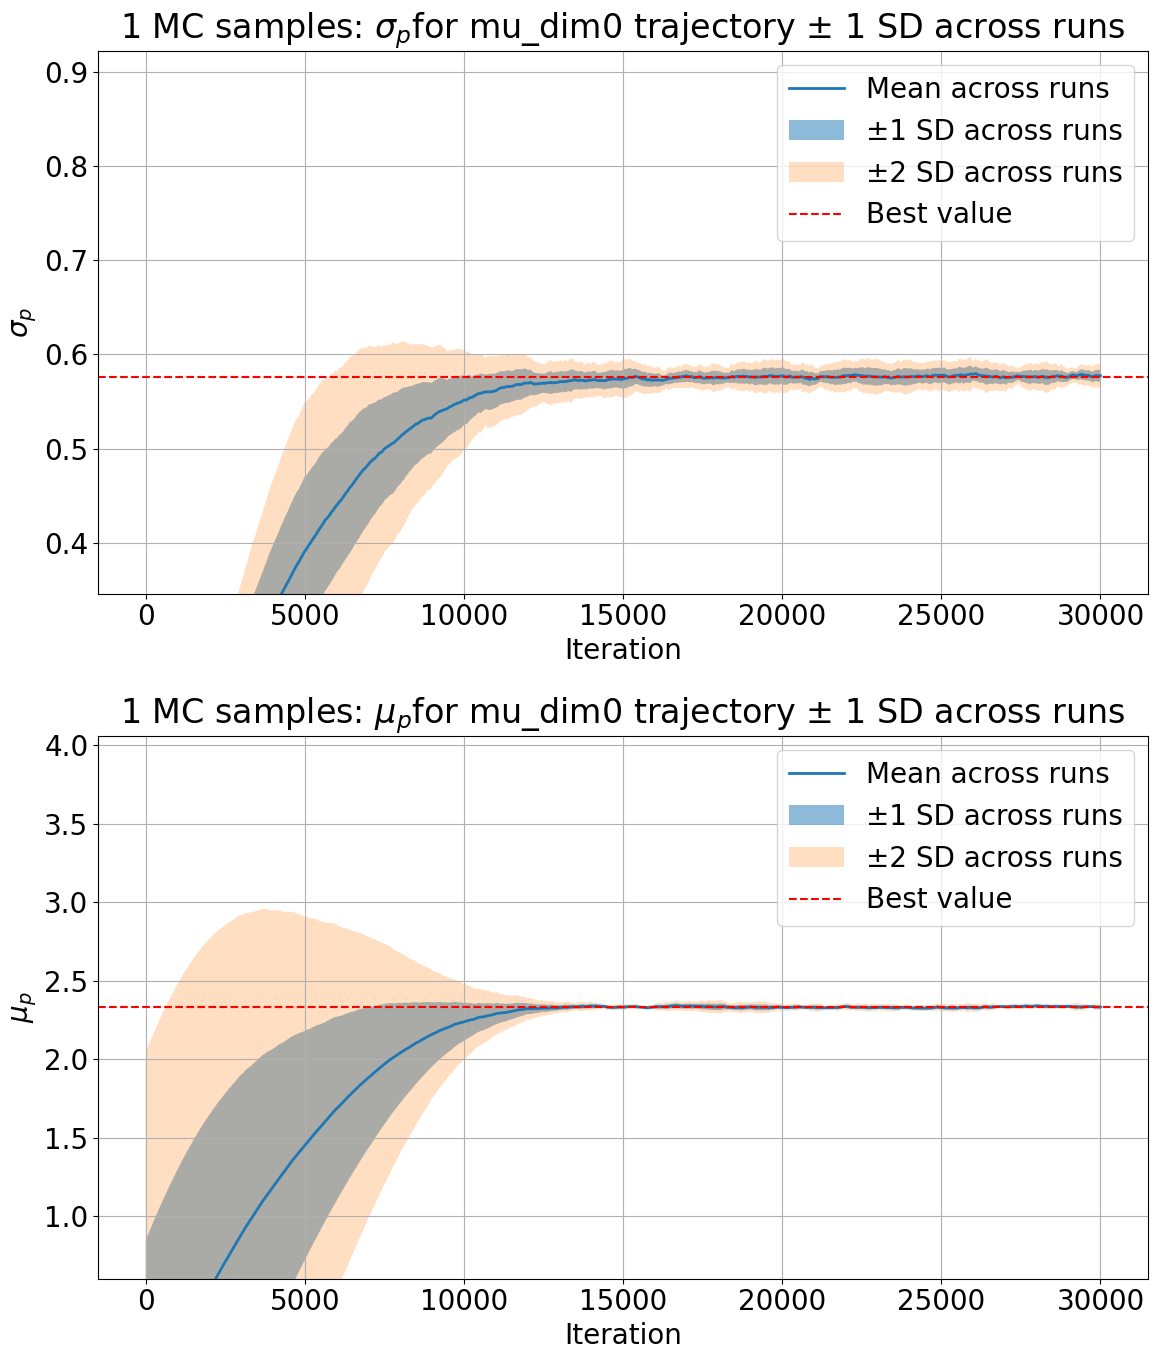

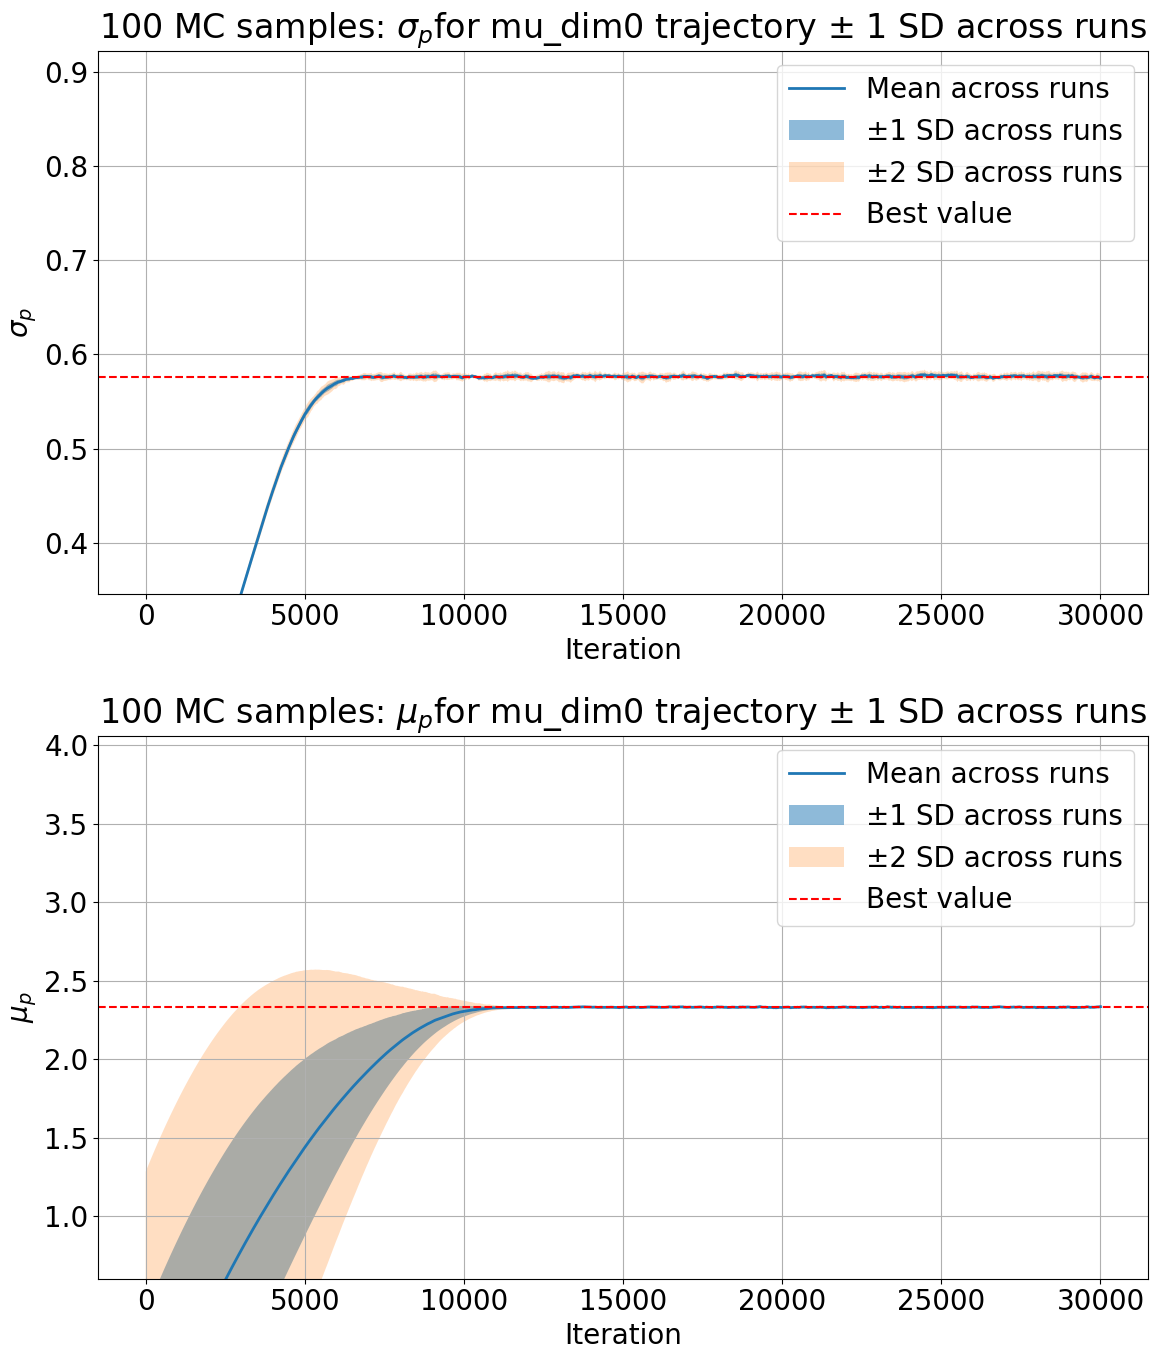

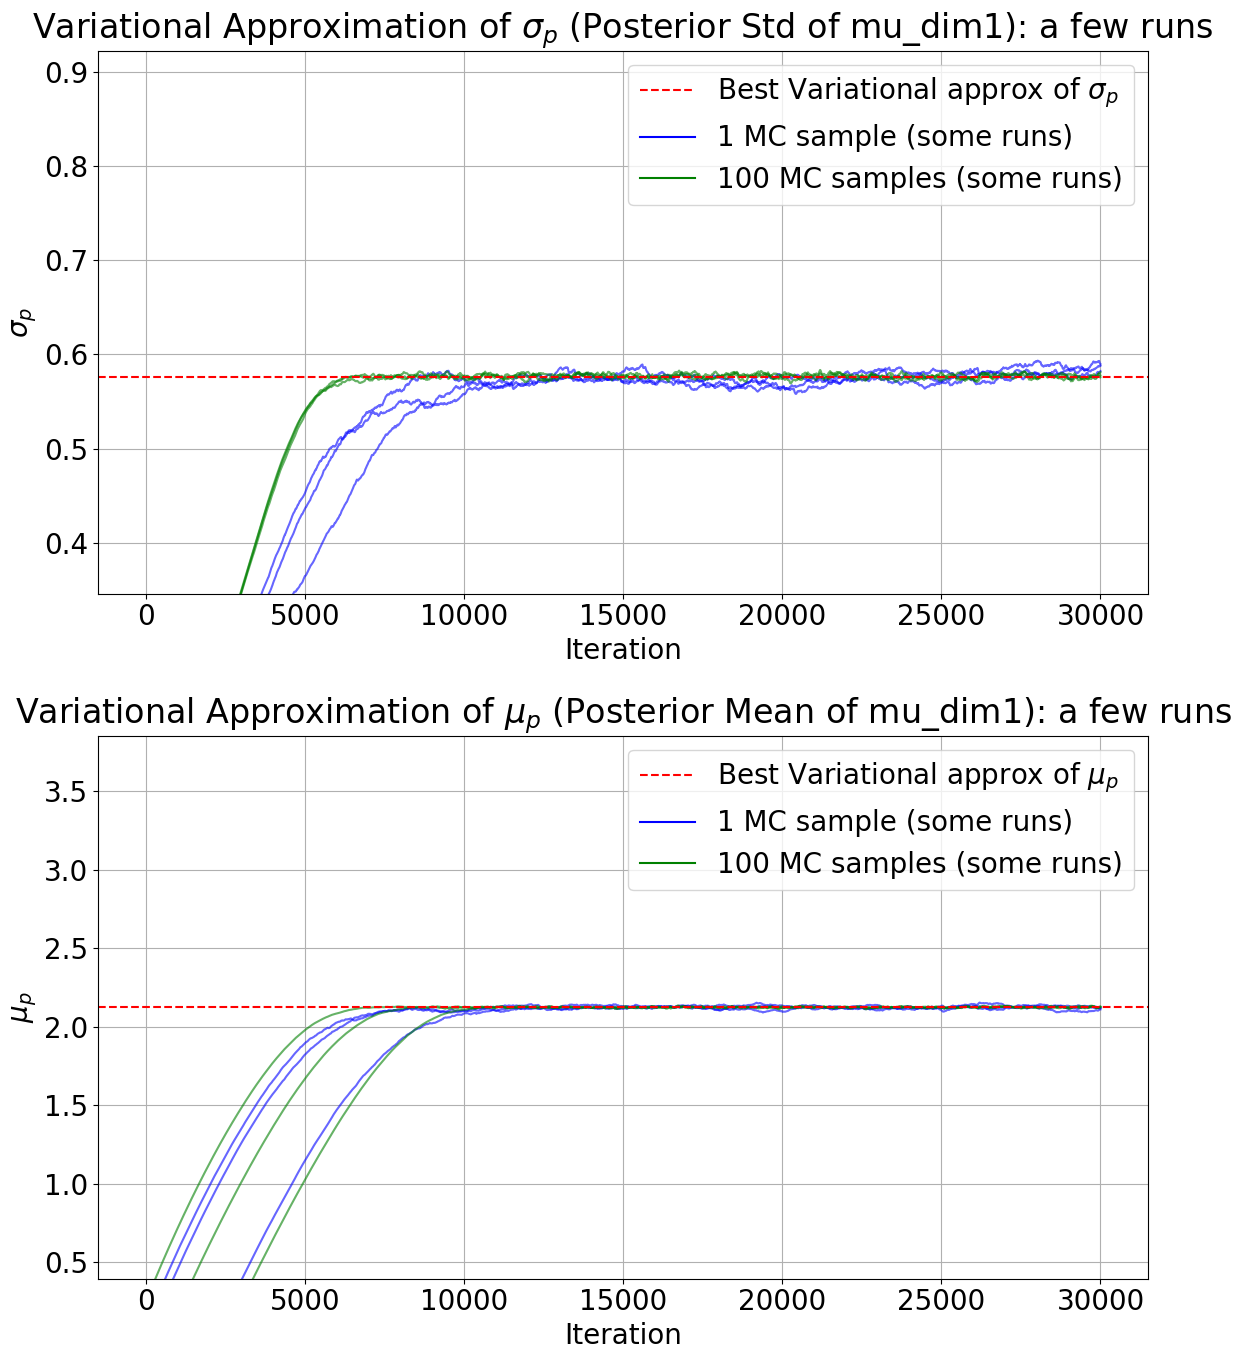

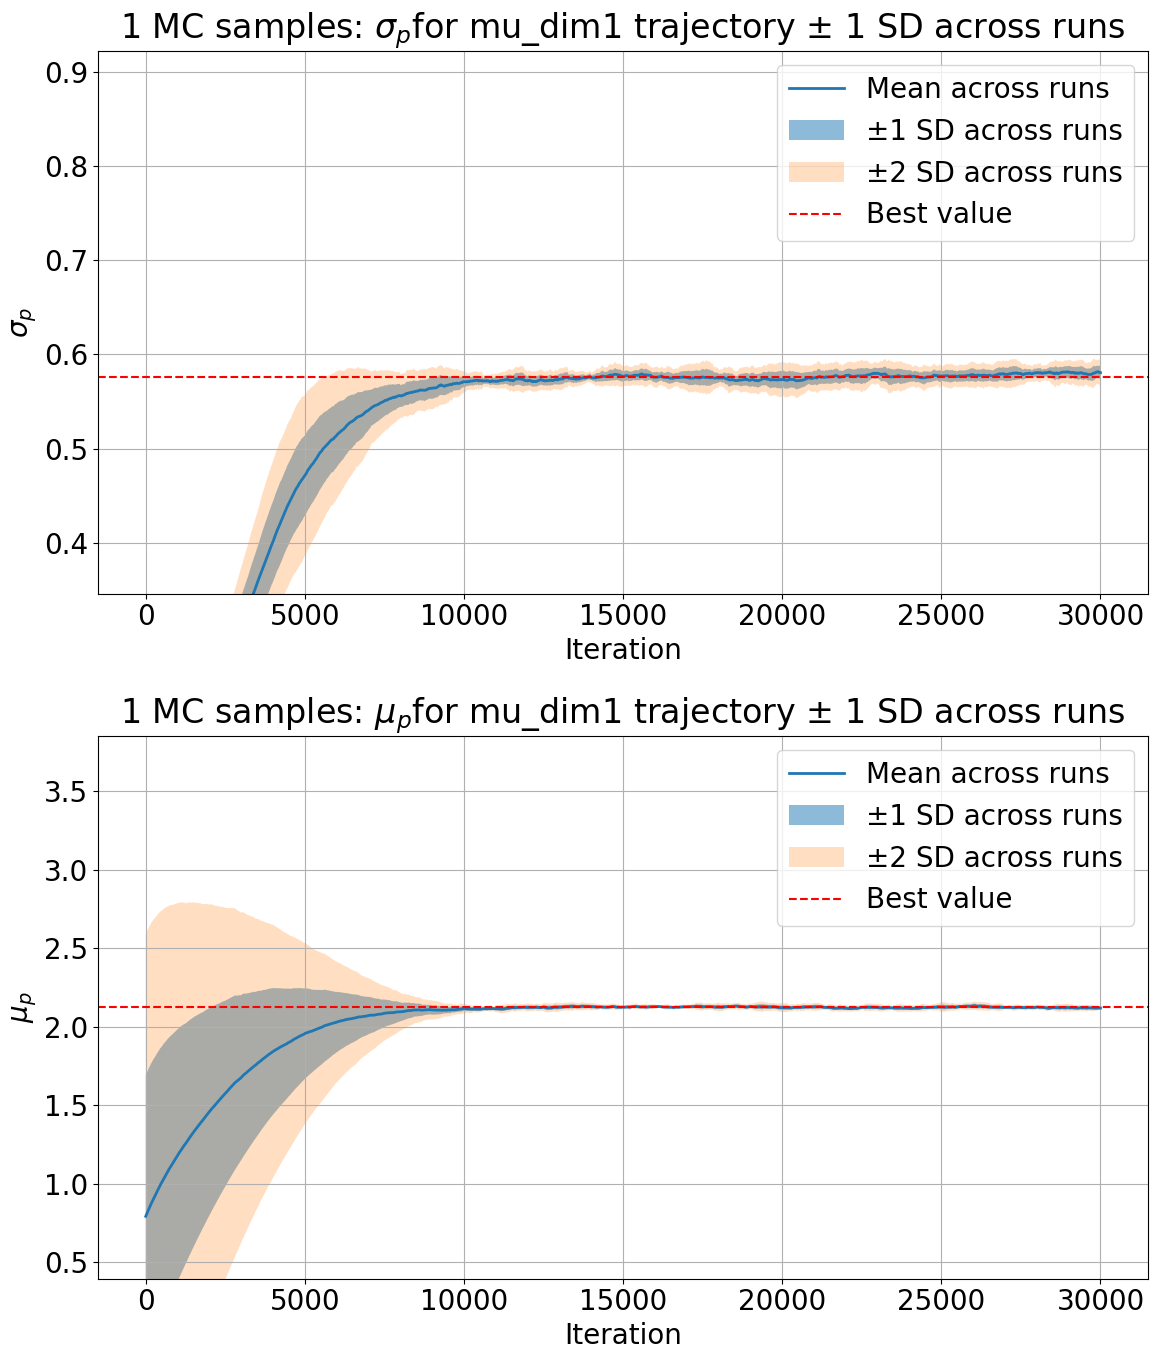

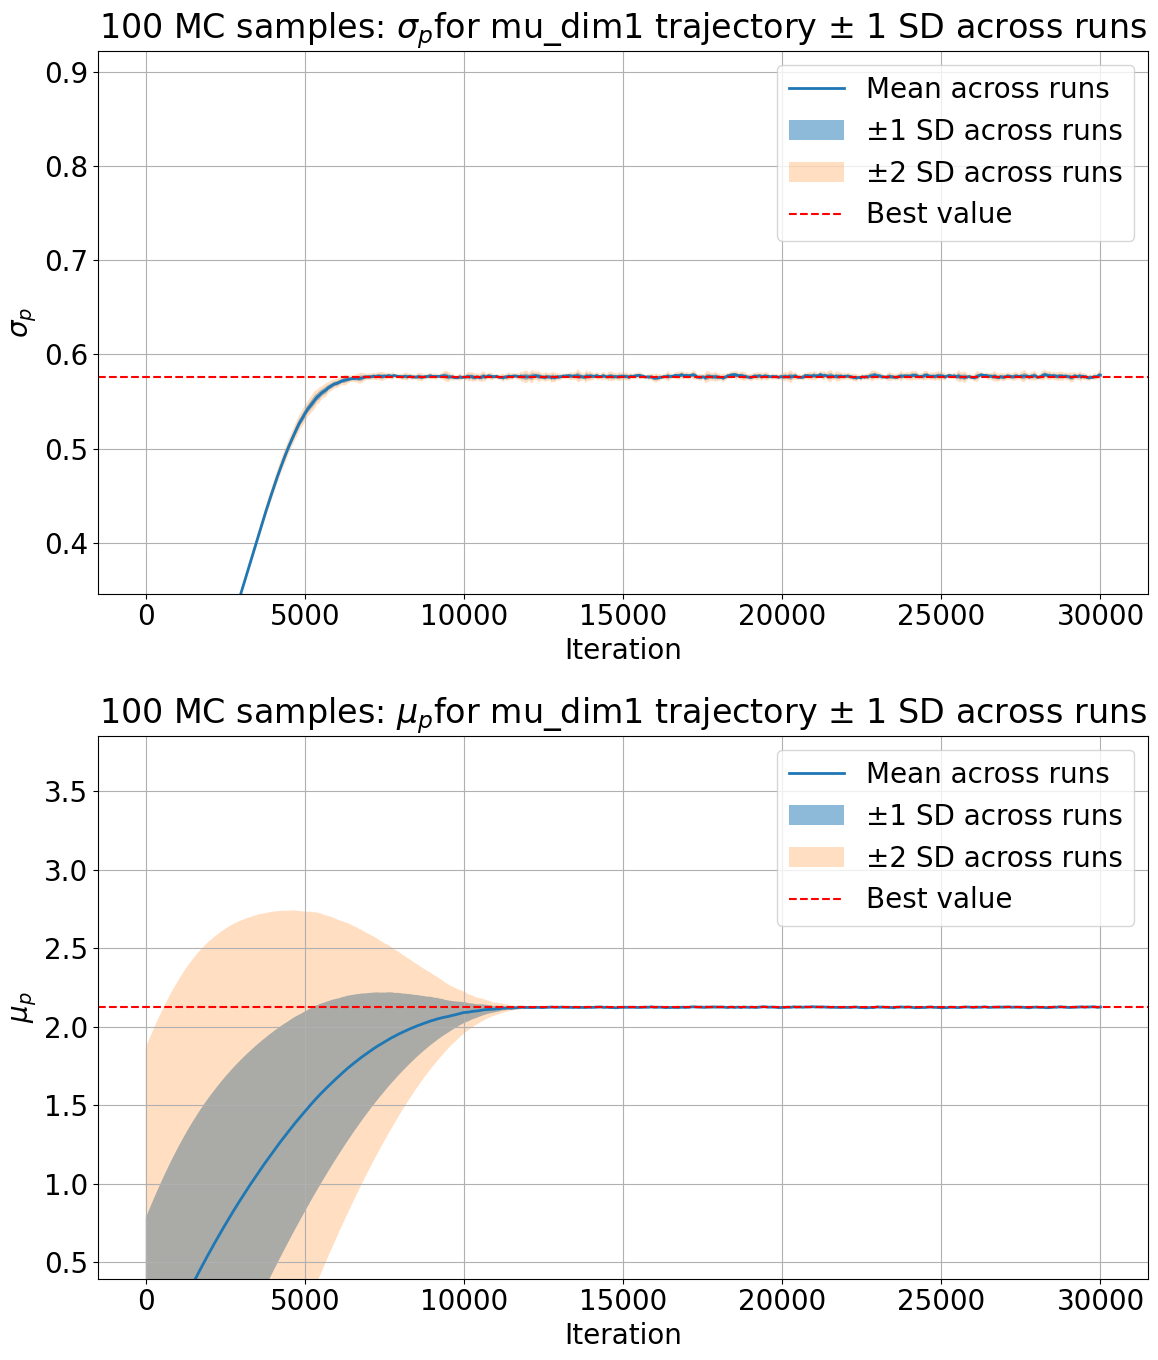

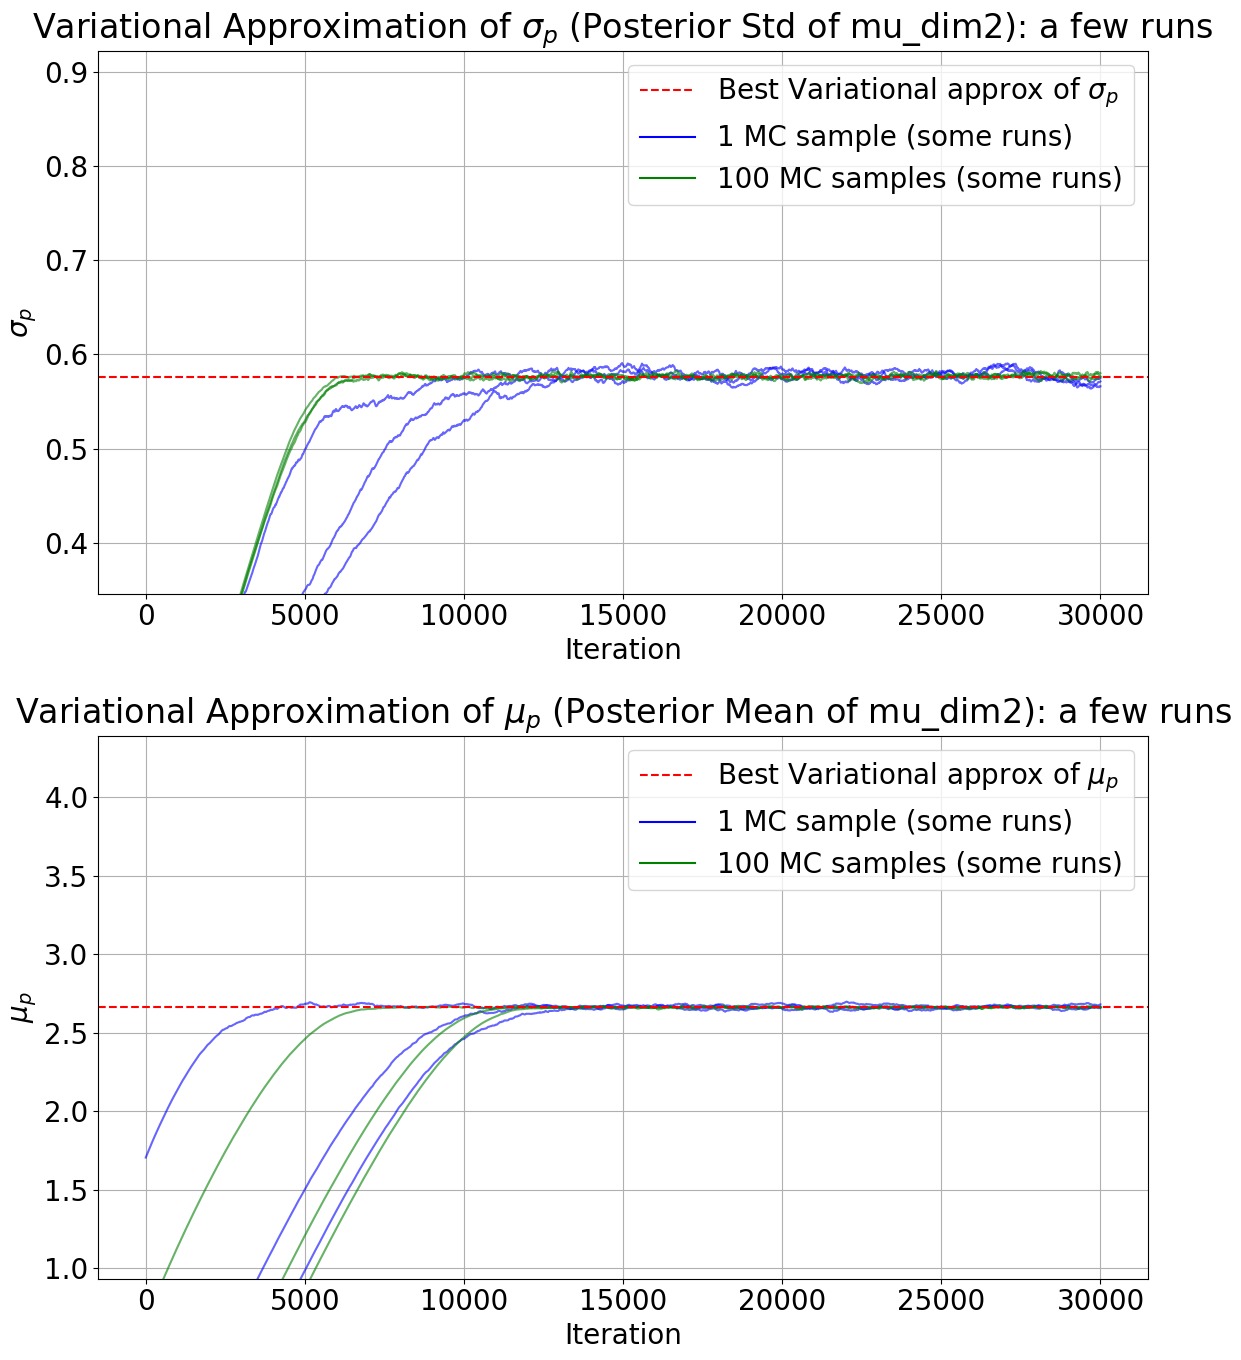

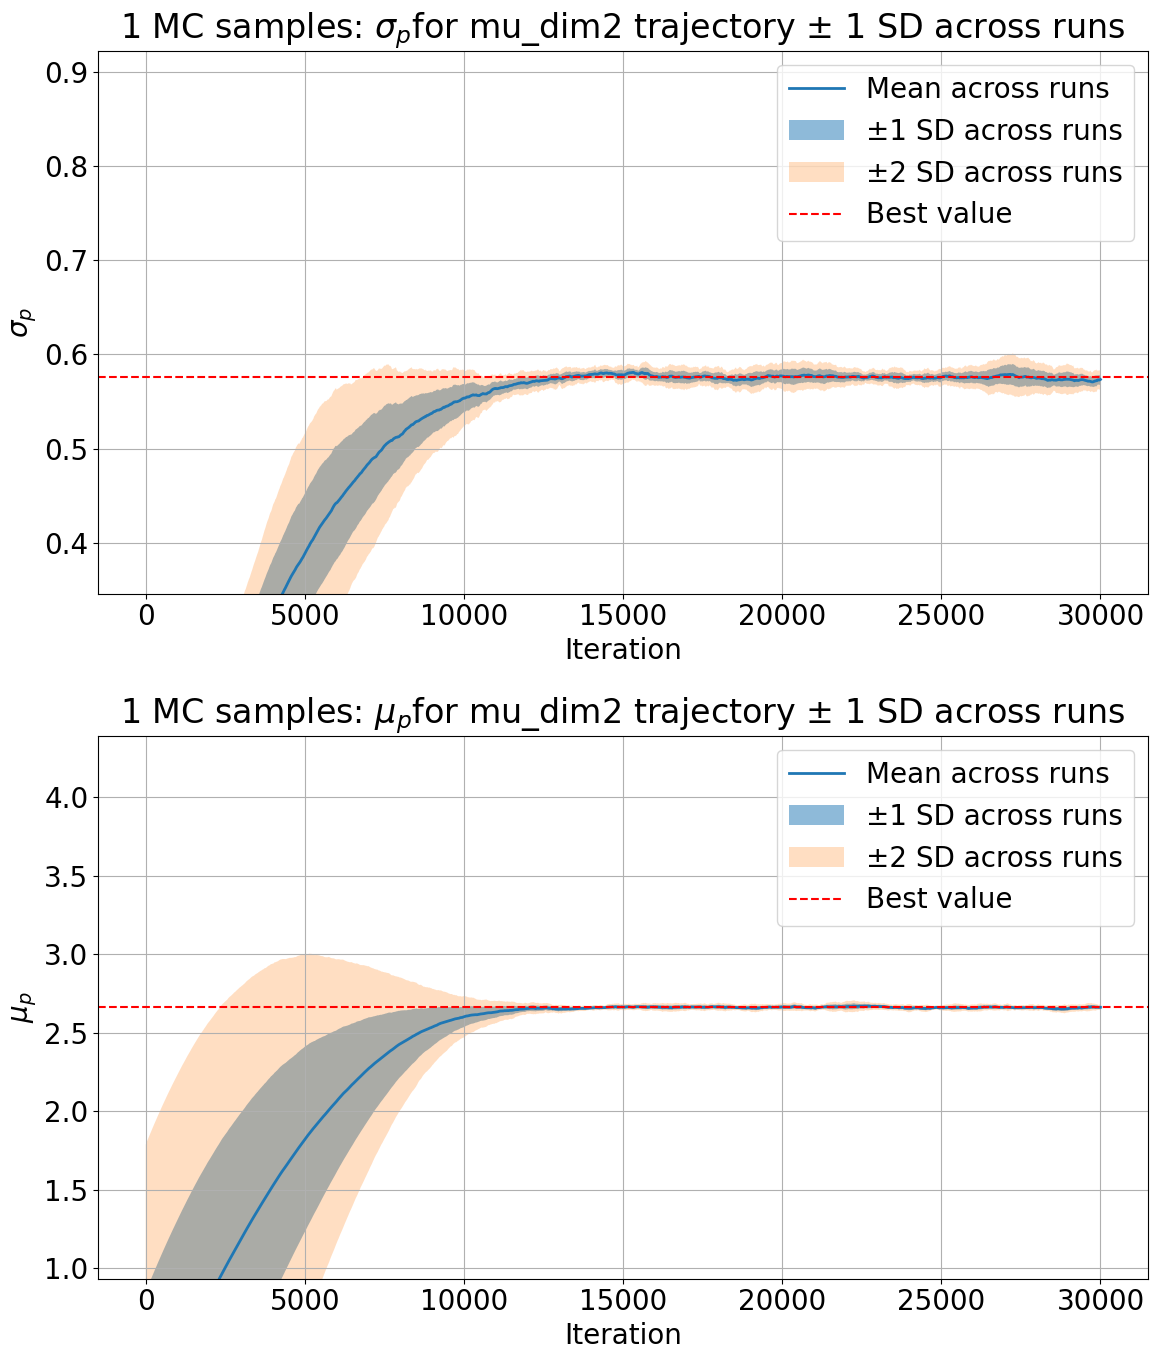

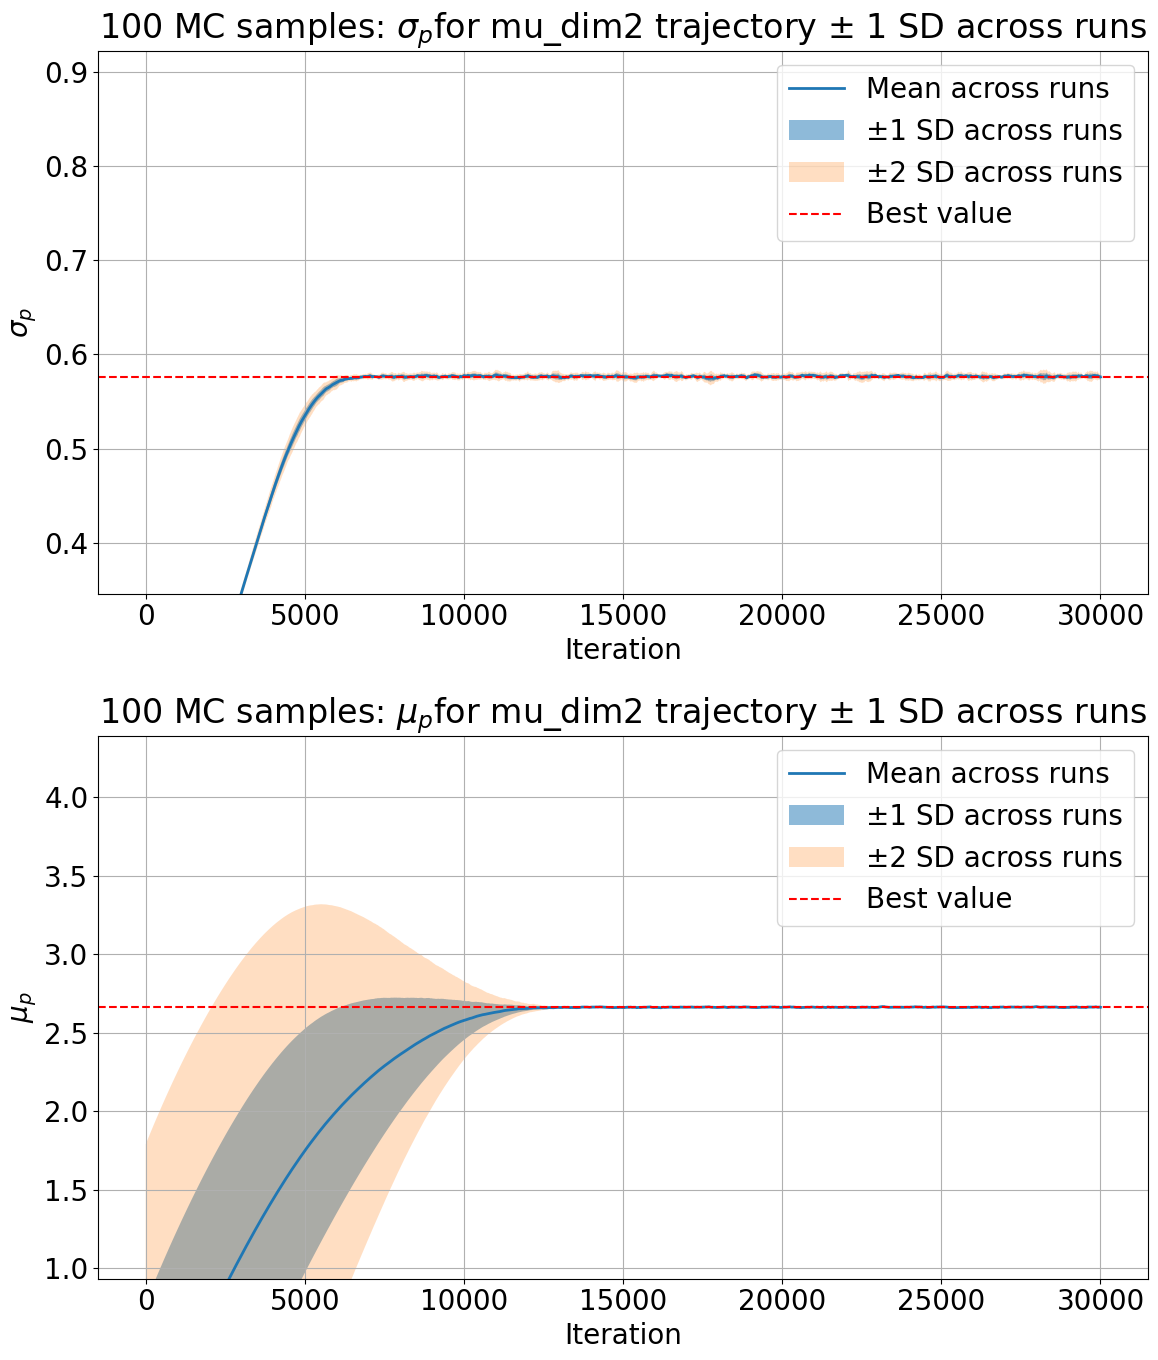

In [24]:

from modulars.plot_rr import plot_some_dims_multid
which_dims = [0, 1, 2]
plot_some_dims_multid(
    single_means, single_stds, multi_means, multi_stds,
    true_mu_post, true_sigma_post, 'mu', dim,
    which_dims, k=3
)

In [25]:
single_means.shape

(10, 30000, 40)

In [26]:
len(results)

10

In [27]:
len(results[0])

4

In [28]:
np.stack(results[0], axis=0).shape

(4, 30000, 40)

In [29]:
import matplotlib.pyplot as plt
from modulars.numpyro_rr_test import fit_multid_fullrank_covariance

fullrank_mu_post, fullrank_cov_post = fit_multid_fullrank_covariance(
    0, model, observed_data, 100_000,
    dim=40
)

fullrank_offdiag = fullrank_cov_post.copy()
np.fill_diagonal(fullrank_offdiag, 0.0)


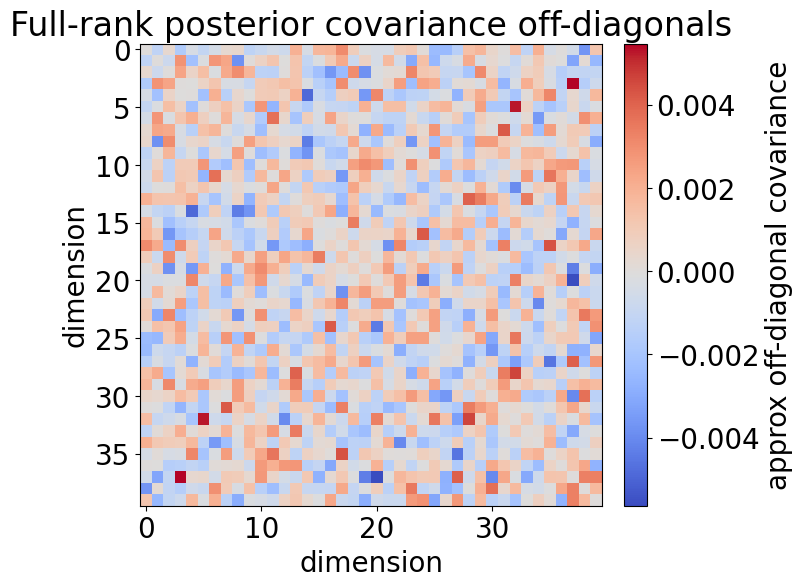

max |offdiag|: 0.0056371572
mean |offdiag|: 0.0013146137
max relative offdiag: 0.009780102287609114
mean relative offdiag: 0.00228076966348886


In [30]:

plt.figure(figsize=(7, 6))
im = plt.imshow(fullrank_offdiag, cmap='coolwarm')
plt.colorbar(im, fraction=0.046, pad=0.04, label='approx off-diagonal covariance')
plt.title('Full-rank posterior covariance off-diagonals')
plt.xlabel('dimension')
plt.ylabel('dimension')
plt.show()

upper_idx = np.triu_indices(dim, k=1)
upper_offdiag = np.abs(fullrank_offdiag[upper_idx])
print('max |offdiag|:', upper_offdiag.max())
print('mean |offdiag|:', upper_offdiag.mean())

print('max relative offdiag:', (upper_offdiag / true_sigma_post[0]).max())
print('mean relative offdiag:', (upper_offdiag / true_sigma_post[0]).mean())


### Why a correlation heatmap?

A covariance heatmap is useful, but raw covariance magnitudes still depend on the marginal scales of each dimension.
In the diagonal-truth case we really care about whether full-rank VI is inventing *spurious dependence*, so it is usually clearer to look at the correlation matrix instead.
Correlation rescales each off-diagonal entry by $\sqrt{\Sigma_{ii} \Sigma_{jj}}$, which puts every pair on the same interpretable scale from -1 to 1.


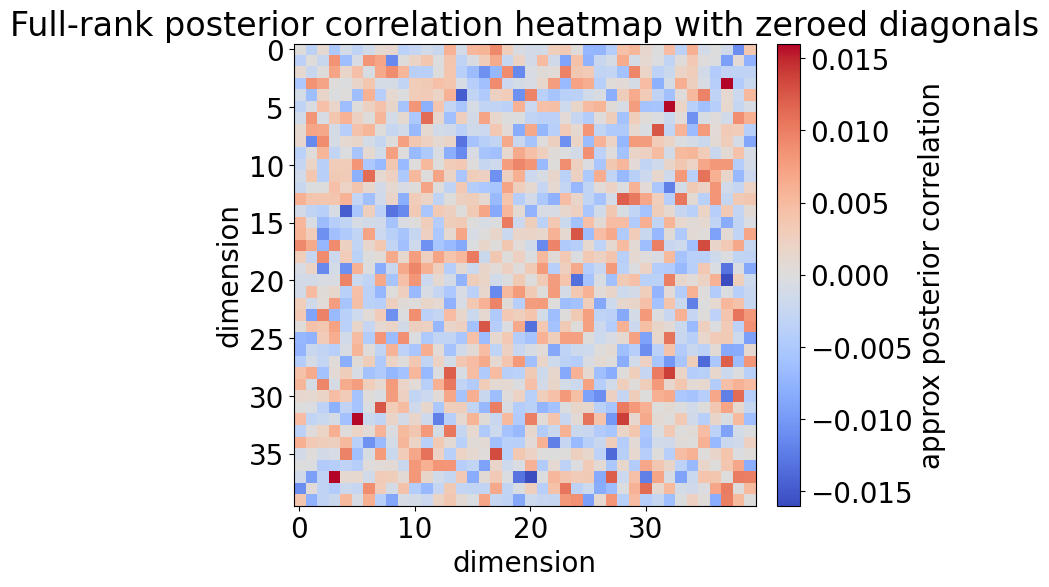

max |offdiag correlation|: 0.016981725
mean |offdiag correlation|: 0.0039546927


In [35]:
fullrank_std_post = np.sqrt(np.diag(fullrank_cov_post))
fullrank_corr_post = fullrank_cov_post / np.outer(fullrank_std_post, fullrank_std_post)

plt.figure(figsize=(7, 6))
np.fill_diagonal(fullrank_corr_post, 0.0)
im = plt.imshow(fullrank_corr_post, cmap='coolwarm', vmin=-0.016, vmax=0.016)
plt.colorbar(im, fraction=0.046, pad=0.04, label='approx posterior correlation')
plt.title('Full-rank posterior correlation heatmap with zeroed diagonals')
plt.xlabel('dimension')
plt.ylabel('dimension')
plt.show()

corr_offdiag = fullrank_corr_post.copy()
np.fill_diagonal(corr_offdiag, 0.0)
upper_corr_offdiag = np.abs(corr_offdiag[np.triu_indices(dim, k=1)])
print('max |offdiag correlation|:', upper_corr_offdiag.max())
print('mean |offdiag correlation|:', upper_corr_offdiag.mean())
